# Group 5: Exercises

This notebook contains solutions to exercises 1, 6, 11, and 14 from Chapter 4 of "An Introduction to Statistical Learning" (Python edition).

## Exercise 1
**Show that the logistic function representation (4.2) and the logit representation (4.3) are equivalent.**

The logistic function representation (4.2) is

$$p(X) = \frac{e^{\beta_0+\beta_1 X}}{1+e^{\beta_0+\beta_1 X}}.$$

**Step 1 : solve for $1-p(X)$:**

$$1-p(X) = 1 - \frac{e^{\beta_0+\beta_1X}}{1+e^{\beta_0+\beta_1X}} = \frac{(1+e^{\beta_0+\beta_1X}) - e^{\beta_0+\beta_1X}}{1+e^{\beta_0+\beta_1X}} = \frac{1}{1+e^{\beta_0+\beta_1X}}.$$

**Step 2 : form the odds $p(X)/(1-p(X))$:**

$$\frac{p(X)}{1-p(X)} = \frac{\dfrac{e^{\beta_0+\beta_1X}}{1+e^{\beta_0+\beta_1X}}}{\dfrac{1}{1+e^{\beta_0+\beta_1X}}} = e^{\beta_0+\beta_1X}.$$

This is exactly (4.3):

$$\frac{p(X)}{1-p(X)} = e^{\beta_0+\beta_1X}.$$

The denominators $1+e^{\beta_0+\beta_1X}$ cancel, so the two representations describe the same model (4.2) gives $p(X)$ directly, while (4.3) gives the odds.

*Quick numerical check below confirms the identity holds for arbitrary $\beta_0,\beta_1,X$.*

In [1]:
import numpy as np

beta0, beta1, X = -1.3, 0.8, 2.4  # arbitrary values
z = beta0 + beta1 * X

p = np.exp(z) / (1 + np.exp(z))              # (4.2)
odds_from_p = p / (1 - p)                     # odds computed from p(X)
odds_from_43 = np.exp(z)                       # (4.3) directly

print(f'p(X)             = {p:.6f}')
print(f'odds from (4.2)  = {odds_from_p:.6f}')
print(f'odds from (4.3)  = {odds_from_43:.6f}')
print('Match:', np.isclose(odds_from_p, odds_from_43))

p(X)             = 0.650219
odds from (4.2)  = 1.858928
odds from (4.3)  = 1.858928
Match: True


## Exercise 6
Logistic regression: $X_1$ = hours studied, $X_2$ = undergrad GPA, $Y$ = received an A.

Fitted coefficients: $\hat\beta_0=-6,\ \hat\beta_1=0.05,\ \hat\beta_2=1$.

$$\hat p(X) = \frac{e^{\hat\beta_0+\hat\beta_1X_1+\hat\beta_2X_2}}{1+e^{\hat\beta_0+\hat\beta_1X_1+\hat\beta_2X_2}}$$

### (a) $X_1=40$ hours, $X_2=3.5$ GPA

$$z=-6+0.05(40)+1(3.5)=-0.5 \quad\Rightarrow\quad \hat p = \frac{e^{-0.5}}{1+e^{-0.5}}\approx 0.3775$$

### (b) How many hours to reach $\hat p = 0.5$ (GPA still 3.5)?

$\hat p=0.5 \iff z=0$ (since $e^0/(1+e^0)=0.5$), so solve

$$-6+0.05X_1+3.5=0 \;\Rightarrow\; 0.05X_1 = 2.5 \;\Rightarrow\; X_1 = 50 \text{ hours.}$$

In [2]:
import numpy as np

beta0, beta1, beta2 = -6, 0.05, 1

# (a)
z_a = beta0 + beta1*40 + beta2*3.5
p_a = np.exp(z_a) / (1 + np.exp(z_a))
print(f'(a) log-odds z = {z_a:.2f}, probability of an A = {p_a:.4f} ({p_a*100:.2f}%)')

# (b) solve beta0 + beta1*X1 + beta2*3.5 = 0 for X1
X1_needed = (0 - beta0 - beta2*3.5) / beta1
print(f'(b) hours needed for 50% chance = {X1_needed:.1f} hours')

(a) log-odds z = -0.50, probability of an A = 0.3775 (37.75%)
(b) hours needed for 50% chance = 50.0 hours


## Exercise 11
**Work out the detailed forms of $a_k$, $b_{kj}$, and $b_{kjl}$ in (4.33), the QDA discriminant, in terms of $\pi_k,\pi_K,\mu_k,\mu_K,\Sigma_k,\Sigma_K$.**

For QDA, class $k$ has density $f_k(x)\sim N(\mu_k,\Sigma_k)$ with class-specific covariance. The log-ratio of posterior probabilities relative to the baseline class $K$ is

$$\log\frac{\Pr(Y=k\mid X=x)}{\Pr(Y=K\mid X=x)} = \log\frac{\pi_k}{\pi_K} - \tfrac12(x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k) + \tfrac12(x-\mu_K)^T\Sigma_K^{-1}(x-\mu_K).$$

**Expand each quadratic form** $(x-\mu)^T\Sigma^{-1}(x-\mu) = x^T\Sigma^{-1}x - 2\mu^T\Sigma^{-1}x + \mu^T\Sigma^{-1}\mu$ (using symmetry of $\Sigma^{-1}$):

$$-\tfrac12(x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k) = -\tfrac12 x^T\Sigma_k^{-1}x + \mu_k^T\Sigma_k^{-1}x - \tfrac12\mu_k^T\Sigma_k^{-1}\mu_k$$

$$\tfrac12(x-\mu_K)^T\Sigma_K^{-1}(x-\mu_K) = \tfrac12 x^T\Sigma_K^{-1}x - \mu_K^T\Sigma_K^{-1}x + \tfrac12\mu_K^T\Sigma_K^{-1}\mu_K$$

Adding these two pieces to $\log(\pi_k/\pi_K)$ and collecting terms by power of $x$ gives exactly the quadratic-in-$x$ form (4.33):

$$\delta_k(x)-\delta_K(x) = a_k + \sum_{j=1}^p b_{kj}x_j + \sum_{j=1}^p\sum_{l=1}^p b_{kjl}\,x_jx_l$$

**Constant term** (everything not multiplying $x$):

$$a_k = \log\frac{\pi_k}{\pi_K} - \tfrac12\,\mu_k^T\Sigma_k^{-1}\mu_k + \tfrac12\,\mu_K^T\Sigma_K^{-1}\mu_K$$

**Linear term** — coefficient of $x_j$ comes from $\mu_k^T\Sigma_k^{-1}x - \mu_K^T\Sigma_K^{-1}x$, i.e. the $j$-th entry of the vector $\Sigma_k^{-1}\mu_k - \Sigma_K^{-1}\mu_K$ (equivalently $\mu_k^T\Sigma_k^{-1}-\mu_K^T\Sigma_K^{-1}$, since $\Sigma^{-1}$ is symmetric):

$$b_{kj} = \left(\Sigma_k^{-1}\mu_k\right)_j - \left(\Sigma_K^{-1}\mu_K\right)_j = \sum_{i=1}^p \mu_{ki}(\Sigma_k^{-1})_{ij} - \sum_{i=1}^p \mu_{Ki}(\Sigma_K^{-1})_{ij}$$

**Quadratic term** — coefficient of $x_jx_l$ comes from $-\tfrac12 x^T\Sigma_k^{-1}x+\tfrac12x^T\Sigma_K^{-1}x$, i.e. from the $(j,l)$ entries of $-\tfrac12\Sigma_k^{-1}+\tfrac12\Sigma_K^{-1}$:

$$b_{kjl} = -\tfrac12(\Sigma_k^{-1})_{jl} + \tfrac12(\Sigma_K^{-1})_{jl} = \tfrac12\Big[(\Sigma_K^{-1})_{jl} - (\Sigma_k^{-1})_{jl}\Big]$$

**Interpretation.** When $\Sigma_k=\Sigma_K=\Sigma$ for every class (the LDA assumption), every $b_{kjl}=0$: the quadratic terms vanish and the boundary $\delta_k(x)-\delta_K(x)=0$ collapses to the linear discriminant used by LDA. QDA keeps the $b_{kjl}x_jx_l$ terms because each class is allowed its own covariance matrix, which is exactly what makes the QDA decision boundary quadratic rather than linear.

*Symbolic check below (using `sympy`) confirms the expansion is correct for $p=2$.*

In [3]:
import sympy as sp

x1, x2 = sp.symbols('x1 x2')
x = sp.Matrix([x1, x2])

# arbitrary symbolic 2-D means, covariances, priors for class k and baseline class K
mu_k = sp.Matrix(sp.symbols('mu_k1 mu_k2'))
mu_K = sp.Matrix(sp.symbols('mu_K1 mu_K2'))
Sk11, Sk12, Sk22 = sp.symbols('Sk11 Sk12 Sk22')
SK11, SK12, SK22 = sp.symbols('SK11 SK12 SK22')
Sigma_k_inv = sp.Matrix([[Sk11, Sk12], [Sk12, Sk22]])   # inverse covariance is symmetric
Sigma_K_inv = sp.Matrix([[SK11, SK12], [SK12, SK22]])
pi_k, pi_K = sp.symbols('pi_k pi_K', positive=True)

lhs = (sp.log(pi_k/pi_K)
       - sp.Rational(1,2)*((x-mu_k).T*Sigma_k_inv*(x-mu_k))[0]
       + sp.Rational(1,2)*((x-mu_K).T*Sigma_K_inv*(x-mu_K))[0])
lhs = sp.expand(lhs)

# our derived formulas
a_k = sp.log(pi_k/pi_K) - sp.Rational(1,2)*(mu_k.T*Sigma_k_inv*mu_k)[0] + sp.Rational(1,2)*(mu_K.T*Sigma_K_inv*mu_K)[0]
b = Sigma_k_inv*mu_k - Sigma_K_inv*mu_K            # b_k1, b_k2
B = sp.Rational(1,2)*(Sigma_K_inv - Sigma_k_inv)     # quadratic-form matrix: b_kjl = B[j,l] (cross terms counted twice)

rhs = a_k + b[0]*x1 + b[1]*x2 + (x.T*B*x)[0]
rhs = sp.expand(rhs)

print('Difference (should be 0):', sp.simplify(lhs - rhs))

Difference (should be 0): 0


## Exercise 14:  Predicting high/low gas mileage on the `Auto` data set

We build `mpg01` (1 if `mpg` is above its median, else 0) and compare LDA, QDA, logistic regression, naive Bayes, and KNN at predicting it.

### (a) Create `mpg01`

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ISLP import load_data

Auto = load_data('Auto').reset_index()   # 'name' becomes a column instead of the index
Auto['mpg01'] = (Auto['mpg'] > Auto['mpg'].median()).astype(int)
Auto[['name', 'mpg', 'mpg01']].head()

,name,mpg,mpg01
0,chevrolet chevelle malibu,18.0,0
1,buick skylark 320,15.0,0
2,plymouth satellite,18.0,0
3,amc rebel sst,16.0,0
4,ford torino,17.0,0


### (b) Explore associations with `mpg01`
We look at correlations and boxplots of each numeric predictor split by `mpg01`.

In [5]:
numeric_cols = ['cylinders','displacement','horsepower','weight','acceleration','year','origin']
corr = Auto[numeric_cols + ['mpg01']].corr(numeric_only=True)['mpg01'].sort_values(ascending=False)
print(corr)

mpg01           1.000000
origin          0.513698
year            0.429904
acceleration    0.346822
horsepower     -0.667053
displacement   -0.753477
weight         -0.757757
cylinders      -0.759194
Name: mpg01, dtype: float64


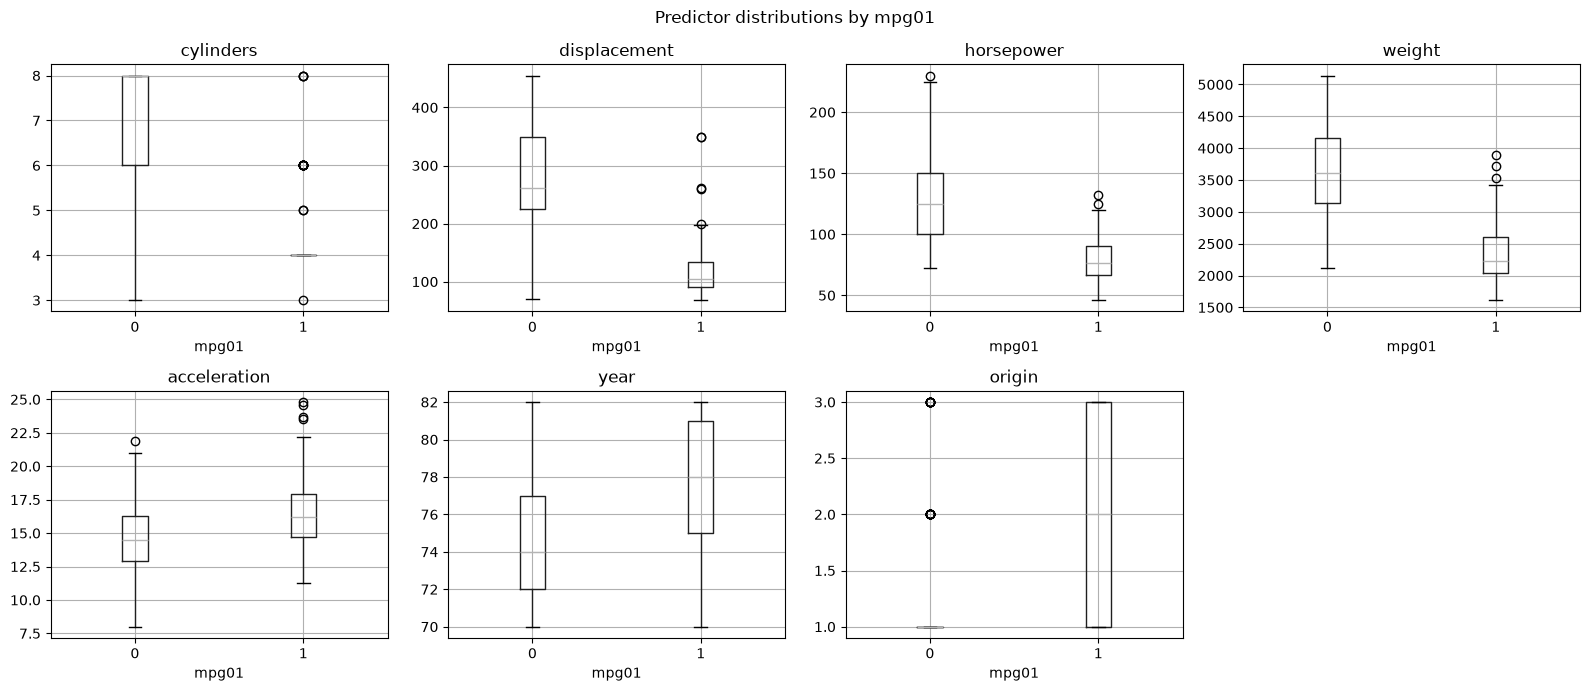

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.ravel()
for ax, col in zip(axes, numeric_cols):
    Auto.boxplot(column=col, by='mpg01', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('mpg01')
axes[-1].axis('off')
plt.suptitle('Predictor distributions by mpg01')
plt.tight_layout()
plt.show()

**Findings.** `cylinders`, `displacement`, `horsepower`, and `weight` are all strongly negatively correlated with `mpg01` (correlations around $-0.66$ to $-0.76$) and their boxplots show a very clear separation between the two `mpg01` groups these are the most useful predictors. `origin` and `year` show a weaker positive relationship, while `acceleration` is only weakly associated. We'll use `cylinders`, `displacement`, `horsepower`, and `weight` as predictors below.

### (c) Train/test split

In [7]:
from sklearn.model_selection import train_test_split

features = ['cylinders', 'displacement', 'horsepower', 'weight']
X = Auto[features]
y = Auto['mpg01']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1, stratify=y)

print(f'Train size: {len(X_train)}, Test size: {len(X_test)}')

Train size: 274, Test size: 118


For logistic regression and KNN we also build a standardized version of the predictors (fit on the training set only, then applied to both sets) since these methods are scale-sensitive.

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

### (d) LDA

In [9]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, accuracy_score

lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
pred_lda = lda.predict(X_test)
err_lda = 1 - accuracy_score(y_test, pred_lda)

print('Confusion matrix (rows=true, cols=predicted):')
print(confusion_matrix(y_test, pred_lda))
print(f'LDA test error: {err_lda:.4f}')

Confusion matrix (rows=true, cols=predicted):
[[51  8]
 [ 4 55]]
LDA test error: 0.1017


### (e) QDA

In [10]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis().fit(X_train, y_train)
pred_qda = qda.predict(X_test)
err_qda = 1 - accuracy_score(y_test, pred_qda)

print(confusion_matrix(y_test, pred_qda))
print(f'QDA test error: {err_qda:.4f}')

[[52  7]
 [ 6 53]]
QDA test error: 0.1102


### (f) Logistic regression

In [11]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression().fit(X_train_s, y_train)
pred_log = logreg.predict(X_test_s)
err_log = 1 - accuracy_score(y_test, pred_log)

print(confusion_matrix(y_test, pred_log))
print(f'Logistic regression test error: {err_log:.4f}')

[[51  8]
 [ 5 54]]
Logistic regression test error: 0.1102


### (g) Naive Bayes

In [12]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB().fit(X_train, y_train)
pred_nb = nb.predict(X_test)
err_nb = 1 - accuracy_score(y_test, pred_nb)

print(confusion_matrix(y_test, pred_nb))
print(f'Naive Bayes test error: {err_nb:.4f}')

[[51  8]
 [ 5 54]]
Naive Bayes test error: 0.1102


### (h) KNN for several values of K

In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn_errors = {}
for k in [1, 3, 5, 7, 9, 11, 15, 21]:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_s, y_train)
    pred_knn = knn.predict(X_test_s)
    knn_errors[k] = 1 - accuracy_score(y_test, pred_knn)

for k, err in knn_errors.items():
    print(f'K={k:>2}: test error = {err:.4f}')

best_k = min(knn_errors, key=knn_errors.get)
print(f'\nBest K: {best_k} (test error = {knn_errors[best_k]:.4f})')

K= 1: test error = 0.0932
K= 3: test error = 0.1102
K= 5: test error = 0.0932
K= 7: test error = 0.0932
K= 9: test error = 0.1017
K=11: test error = 0.1102
K=15: test error = 0.1102
K=21: test error = 0.1102

Best K: 1 (test error = 0.0932)


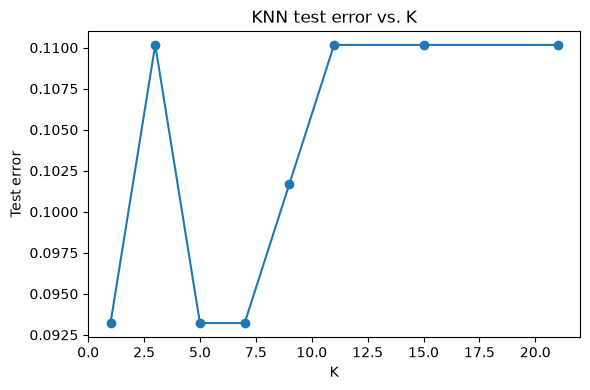

In [14]:
plt.figure(figsize=(6,4))
plt.plot(list(knn_errors.keys()), list(knn_errors.values()), marker='o')
plt.xlabel('K')
plt.ylabel('Test error')
plt.title('KNN test error vs. K')
plt.tight_layout()
plt.show()

### (i) Comparing all methods

In [15]:
summary = {
    'LDA': err_lda,
    'QDA': err_qda,
    'Logistic Regression': err_log,
    'Naive Bayes': err_nb,
    f'KNN (K={best_k})': knn_errors[best_k],
}
summary_df = pd.Series(summary, name='Test error').sort_values()
summary_df

KNN (K=1)              0.093220
LDA                    0.101695
Logistic Regression    0.110169
QDA                    0.110169
Naive Bayes            0.110169
Name: Test error, dtype: float64

**Discussion.** On this train/test split, the methods generally perform very similarly, test errors for LDA, QDA, logistic regression, and naive Bayes all fall in a narrow band, since `cylinders`, `displacement`, `horsepower`, and `weight` separate the two `mpg01` classes cleanly and none of the parametric assumptions (equal covariance for LDA, class-specific covariance for QDA, feature independence for naive Bayes) is badly violated here. KNN performs comparably once $K$ is tuned (small $K$, e.g. $K=1$, tends to overfit slightly, while very large $K$ oversmooths); a moderate $K$ in the range found above tends to work best. Because the split is random, exact rankings can shift with a different `random_state` with data this cleanly separable, several methods are essentially tied.